# SAR Sampling Backend Profiling

**Note:** To run this notebook you must have optional backends installed, e.g. `conda install numpyro blackjax nutpie`

This notebook profiles a fixed SAR model across PyMC sampling backends on a regular polygon grid benchmark.

The comparison keeps the SAR specification and log-determinant method fixed and varies the sampling backend only.

The workflow uses the public bayespecon API end to end:
- `bayespecon.dgp.simulate_sar(..., create_gdf=True)` generates synthetic data and returns a GeoDataFrame
- A libpysal contiguity graph is built from the returned GeoDataFrame
- `bayespecon.SAR(...)` constructs the model
- `SAR.fit(...)` runs each backend

Dataset setup:
- `n_side × n_side` regular polygon grid (obs = n_side²) generated by `bayespecon.dgp`
- one intercept and two continuous regressors
- a SAR data-generating process simulated from `bayespecon.dgp`

Backends compared:
- `c`: PyMC NUTS with the default C-backed `FAST_RUN` compilation mode
- `numba`: PyMC NUTS with `NUMBA` compilation mode
- `numpyro`: JAX-backed NUTS via NumPyro
- `blackjax`: JAX-backed NUTS via BlackJAX
- `nutpie`: Rust + Numba NUTS via nutpie

The notebook records runtime, posterior means, and divergence counts. Backends that are unavailable in the current environment are skipped automatically.


In [1]:
import importlib.util
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from libpysal import graph

from bayespecon import SAR, dgp

In [2]:
PROFILE_CFG = {
    "n_side": 16,  # grid side; obs = n_side² = 256
    "draws": 250,
    "tune": 250,
    "chains": 4,
    "cores": 2,
    "seed": 2026,
    "logdet_method": "eigenvalue",
}

BACKENDS = {
    "c": {
        "nuts_sampler": "pymc",
        "compile_kwargs": {"mode": "FAST_RUN"},
        "requires": [],
    },
    "numba": {
        "nuts_sampler": "pymc",
        "compile_kwargs": {"mode": "NUMBA"},
        "requires": ["numba"],
    },
    "numpyro": {
        "nuts_sampler": "numpyro",
        "compile_kwargs": None,
        "requires": ["numpyro"],
    },
    "blackjax": {
        "nuts_sampler": "blackjax",
        "compile_kwargs": None,
        "requires": ["blackjax"],
    },
    "nutpie": {
        "nuts_sampler": "nutpie",
        "compile_kwargs": None,
        "requires": ["nutpie"],
    },
}

TRUE_BETA = np.array([1.0, 0.8, -0.5], dtype=np.float64)
TRUE_RHO = 0.35
TRUE_SIGMA = 0.7

In [ ]:
def backend_available(requirements: list[str]) -> bool:
    return all(importlib.util.find_spec(name) is not None for name in requirements)


def simulate_sar_data(seed: int, n_side: int = 16):
    """Simulate SAR data on an n_side × n_side polygon grid.

    Calls ``dgp.simulate_sar`` with ``create_gdf=True``, then builds a
    libpysal contiguity graph from the returned GeoDataFrame.
    """
    rng = np.random.default_rng(seed)
    gdf = dgp.simulate_sar(
        n=n_side,
        rho=TRUE_RHO,
        beta=TRUE_BETA,
        sigma=TRUE_SIGMA,
        rng=rng,
        create_gdf=True,
    )
    W_graph = graph.Graph.build_contiguity(gdf, rook=True).transform("r")
    y = gdf["y"].to_numpy()
    X_cols = [c for c in gdf.columns if c.startswith("X_")]
    X = gdf[X_cols].to_numpy()
    return gdf, y, X, W_graph


def fit_backend(backend_name: str, y: np.ndarray, X: np.ndarray, W) -> dict:
    cfg = BACKENDS[backend_name]
    if not backend_available(cfg["requires"]):
        return {
            "backend": backend_name,
            "available": False,
            "total_time_s": np.nan,
            "rho_hat": np.nan,
            "beta_0_hat": np.nan,
            "beta_1_hat": np.nan,
            "beta_2_hat": np.nan,
            "divergences": np.nan,
            "error": "missing optional dependency",
        }

    t0 = time.perf_counter()
    try:
        model = SAR(
            y=y,
            X=X,
            W=W,
            logdet_method=PROFILE_CFG["logdet_method"],
        )
        idata = model.fit(
            sampler="nuts",
            draws=PROFILE_CFG["draws"],
            tune=PROFILE_CFG["tune"],
            chains=PROFILE_CFG["chains"],
            cores=PROFILE_CFG["cores"],
            random_seed=PROFILE_CFG["seed"],
            progressbar=False,
            compute_convergence_checks=False,
            nuts_sampler=cfg["nuts_sampler"],
            compile_kwargs=cfg["compile_kwargs"],
        )
        elapsed_s = time.perf_counter() - t0

        beta_hat = idata.posterior["beta"].mean(("chain", "draw")).to_numpy()
        rho_hat = float(idata.posterior["rho"].mean(("chain", "draw")).to_numpy())
        divergences = int(idata.sample_stats["diverging"].sum().to_numpy())

        return {
            "backend": backend_name,
            "available": True,
            "total_time_s": elapsed_s,
            "rho_hat": rho_hat,
            "beta_0_hat": float(beta_hat[0]),
            "beta_1_hat": float(beta_hat[1]),
            "beta_2_hat": float(beta_hat[2]),
            "divergences": divergences,
            "error": "",
        }
    except Exception as exc:
        return {
            "backend": backend_name,
            "available": True,
            "total_time_s": np.nan,
            "rho_hat": np.nan,
            "beta_0_hat": np.nan,
            "beta_1_hat": np.nan,
            "beta_2_hat": np.nan,
            "divergences": np.nan,
            "error": f"{type(exc).__name__}: {exc}",
        }

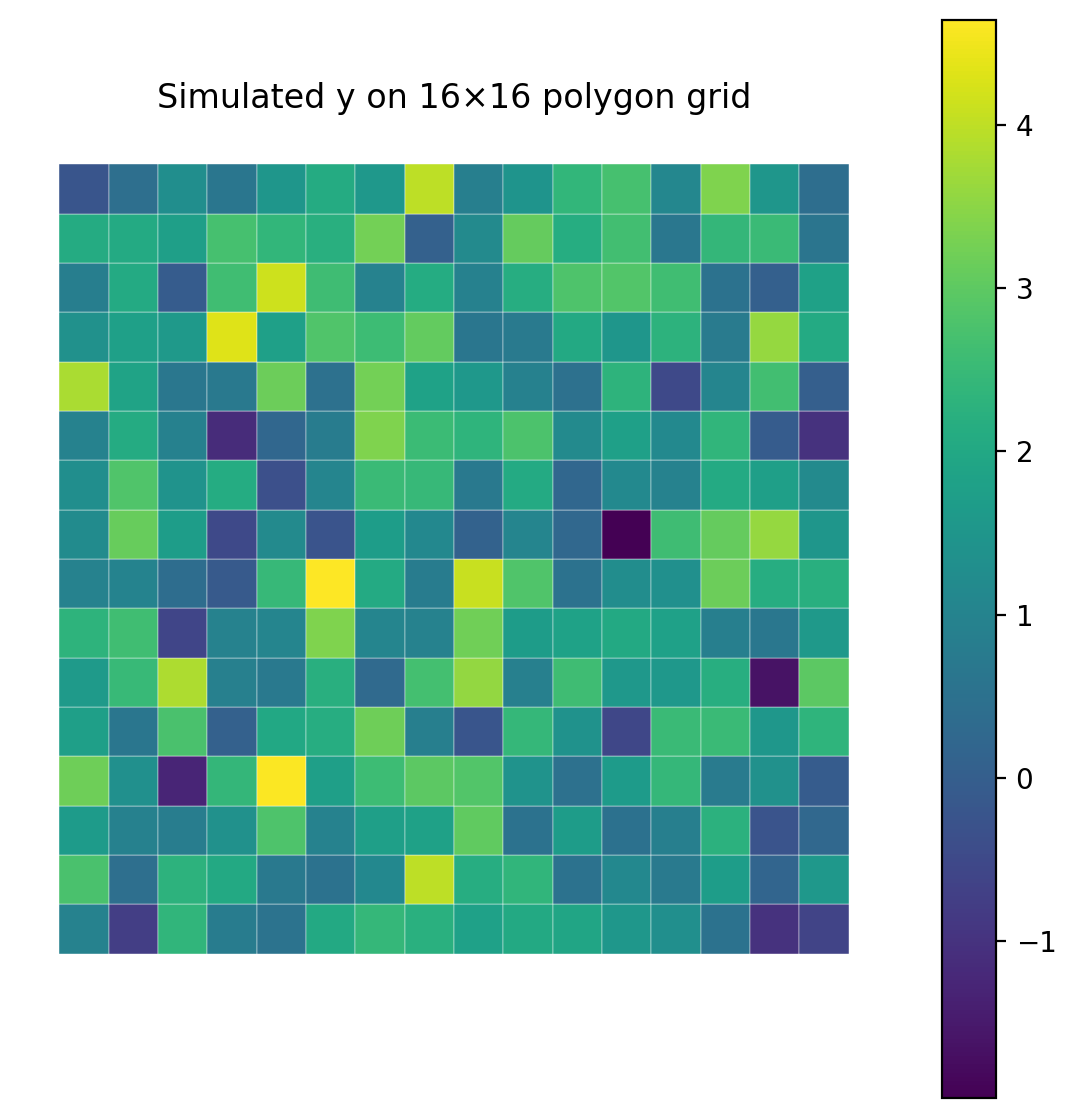

/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_numpy.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)
Initializing NUTS using jitter+adapt_diag...


Profiling backend=c...


Multiprocess sampling (4 chains in 2 jobs)
NUTS: [rho, beta, sigma2]
Sampling 4 chains for 250 tune and 250 draw iterations (1_000 + 1_000 draws total) took 0 seconds.
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_numpy.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)
Initializing NUTS using jitter+adapt_diag...


Profiling backend=numba...


Multiprocess sampling (4 chains in 2 jobs)
NUTS: [rho, beta, sigma2]
Sampling 4 chains for 250 tune and 250 draw iterations (1_000 + 1_000 draws total) took 0 seconds.
/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_numpy.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)


Profiling backend=numpyro...
Profiling backend=blackjax...


/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_numpy.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)


Profiling backend=nutpie...


/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_numpy.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/site-packages/pymc/sampling/mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


,backend,available,total_time_s,rho_hat,beta_0_hat,beta_1_hat,beta_2_hat,divergences,error,rho_abs_error,beta_rmse
0,numba,True,0.823329,0.305057,1.089754,0.770237,-0.448078,0,,0.044943,0.062283
1,nutpie,True,2.384210,0.301690,1.096500,0.767945,-0.448609,0,,0.048310,0.065780
2,blackjax,True,2.600342,0.303826,1.091770,0.769632,-0.446815,0,,0.046174,0.063699
3,numpyro,True,4.691385,0.305089,1.092707,0.771200,-0.446871,0,,0.044911,0.063892
4,c,True,6.129234,0.305057,1.089754,0.770237,-0.448078,0,,0.044943,0.062283


In [4]:
gdf_subset, y, X, W = simulate_sar_data(
    seed=PROFILE_CFG["seed"], n_side=PROFILE_CFG["n_side"]
)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
gdf_subset.plot(
    column="y", cmap="viridis", legend=True, linewidth=0.15, edgecolor="white", ax=ax
)
ax.set_title(
    f"Simulated y on {PROFILE_CFG['n_side']}×{PROFILE_CFG['n_side']} polygon grid"
)
ax.set_axis_off()
plt.show()

rows = []
for backend_name in BACKENDS:
    print(f"Profiling backend={backend_name}...")
    rows.append(fit_backend(backend_name, y, X, W))

results = pd.DataFrame(rows)
results["rho_abs_error"] = (results["rho_hat"] - TRUE_RHO).abs()
results["beta_rmse"] = np.sqrt(
    (
        (
            results[["beta_0_hat", "beta_1_hat", "beta_2_hat"]].to_numpy()
            - TRUE_BETA[None, :]
        )
        ** 2
    ).mean(axis=1)
)
results = results.sort_values(
    ["available", "total_time_s"], ascending=[False, True], na_position="last"
).reset_index(drop=True)
results

In [5]:
display_cols = [
    "backend",
    "available",
    "total_time_s",
    "rho_hat",
    "rho_abs_error",
    "beta_rmse",
    "divergences",
    "error",
]
display(
    results[display_cols].round(
        {"total_time_s": 3, "rho_hat": 3, "rho_abs_error": 3, "beta_rmse": 3}
    )
)

,backend,available,total_time_s,rho_hat,rho_abs_error,beta_rmse,divergences,error
0,numba,True,0.823,0.305,0.045,0.062,0,
1,nutpie,True,2.384,0.302,0.048,0.066,0,
2,blackjax,True,2.600,0.304,0.046,0.064,0,
3,numpyro,True,4.691,0.305,0.045,0.064,0,
4,c,True,6.129,0.305,0.045,0.062,0,


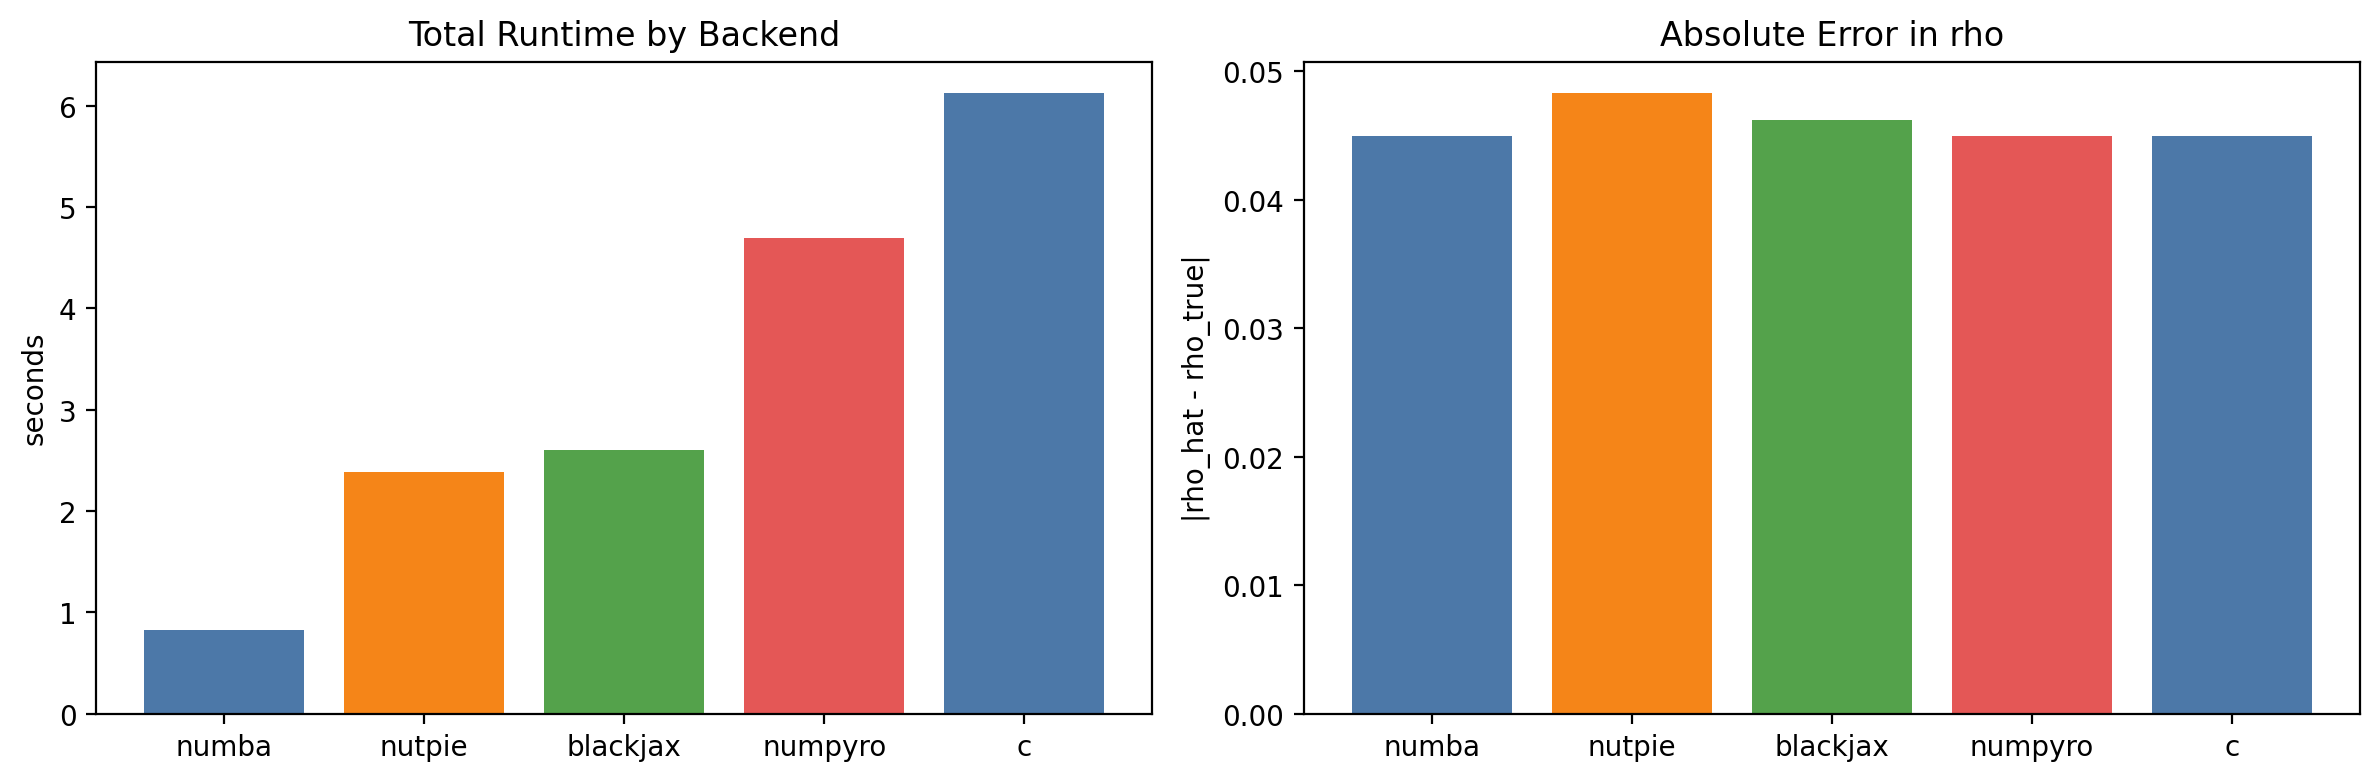

In [6]:
ok = results[results["total_time_s"].notna()].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not ok.empty:
    axes[0].bar(
        ok["backend"],
        ok["total_time_s"],
        color=["#4c78a8", "#f58518", "#54a24b", "#e45756"][: len(ok)],
    )
    axes[0].set_title("Total Runtime by Backend")
    axes[0].set_ylabel("seconds")

    axes[1].bar(
        ok["backend"],
        ok["rho_abs_error"],
        color=["#4c78a8", "#f58518", "#54a24b", "#e45756"][: len(ok)],
    )
    axes[1].set_title("Absolute Error in rho")
    axes[1].set_ylabel("|rho_hat - rho_true|")
else:
    axes[0].text(0.5, 0.5, "No successful backend runs", ha="center", va="center")
    axes[1].text(0.5, 0.5, "No successful backend runs", ha="center", va="center")
    axes[0].set_axis_off()
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [7]:
# Second Example: Larger 40×40 Grid (1600 obs)
# This benchmark repeats the backend comparison on a larger polygon grid.

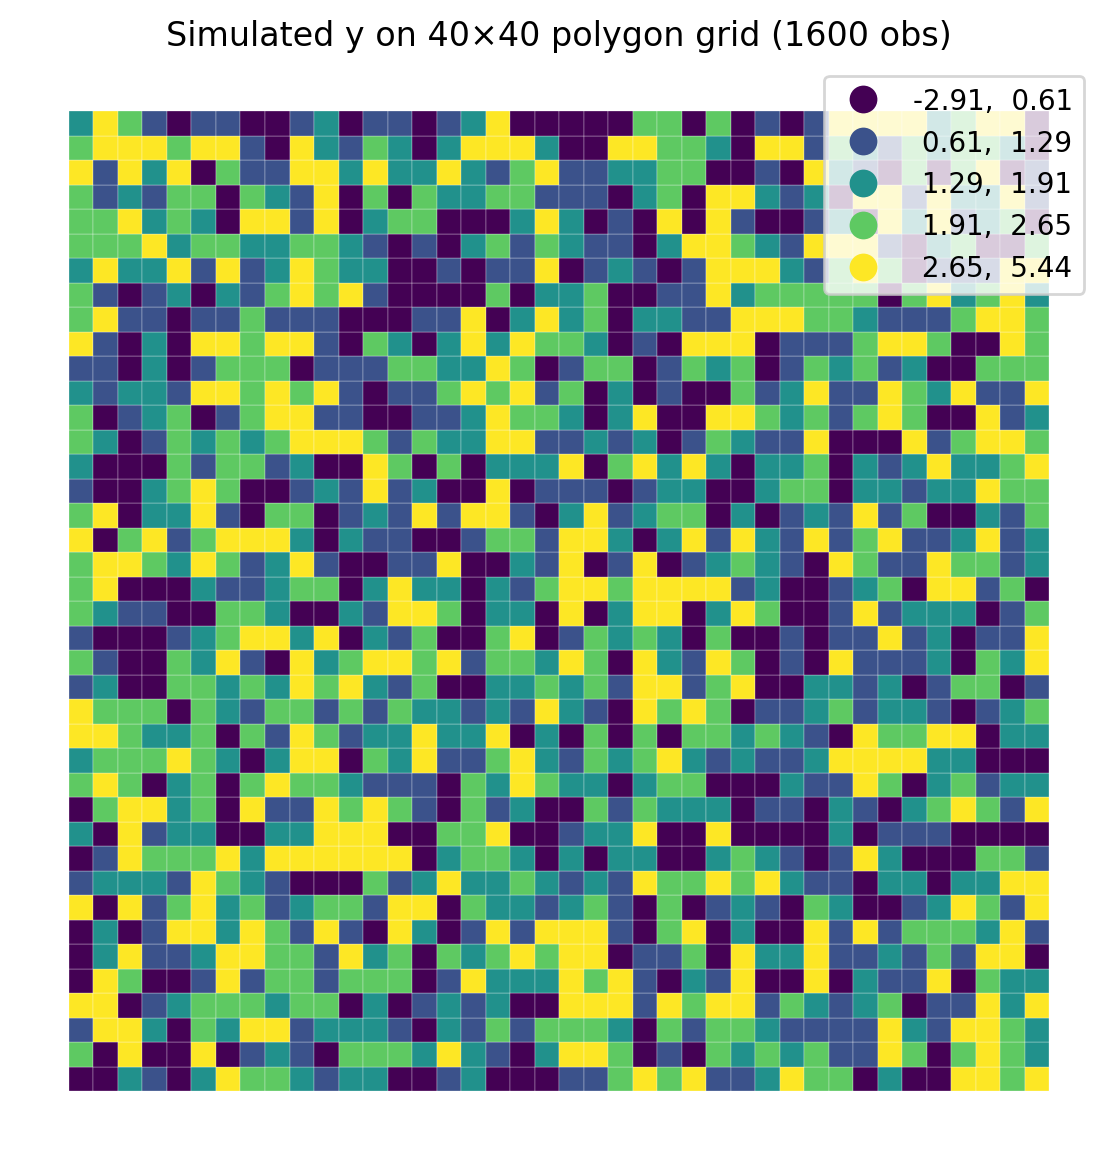

Profiling backend=c on 40×40 grid...


/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_numpy.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [rho, beta, sigma2]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 4 chains for 250 tune and 250 draw iterations (1_000 + 1_000 draws total) took 1 seconds.


Profiling backend=numba on 40×40 grid...


/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_numpy.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [rho, beta, sigma2]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Sampling 4 chains for 250 tune and 250 draw iterations (1_000 + 1_000 draws total) took 1 seconds.


Profiling backend=numpyro on 40×40 grid...


...

Profiling backend=blackjax on 40×40 grid...


/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_numpy.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)


Profiling backend=nutpie on 40×40 grid...


/Users/knaaptime/Dropbox/projects/bayespecon/bayespecon/_logdet/_numpy.py:424: ComplexWarning: Casting complex values to real discards the imaginary part
  W = np.asarray(W, dtype=np.float64)
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/site-packages/pymc/sampling/mcmc.py:361: UserWarning: `idata_kwargs` are currently ignored by the nutpie sampler
  warnings.warn(


,backend,available,total_time_s,rho_hat,rho_abs_error,beta_rmse,divergences,error
0,nutpie,True,2.218,0.353,0.003,0.016,0,
1,numba,True,2.318,0.354,0.004,0.015,0,
2,blackjax,True,2.902,0.353,0.003,0.016,0,
3,c,True,3.421,0.354,0.004,0.015,0,
4,numpyro,True,3.487,0.353,0.003,0.015,0,


In [8]:
gdf_full, y_full, X_full, W_full = simulate_sar_data(
    seed=PROFILE_CFG["seed"], n_side=40
)

gdf_full.plot(
    column="y",
    scheme="quantiles",
    cmap="viridis",
    legend=True,
    linewidth=0.1,
    edgecolor="white",
    figsize=(7, 7),
)
plt.title("Simulated y on 40×40 polygon grid (1600 obs)")
plt.axis("off")
plt.show()

rows_full = []
for backend_name in BACKENDS:
    print(f"Profiling backend={backend_name} on 40×40 grid...")
    rows_full.append(fit_backend(backend_name, y_full, X_full, W_full))

results_full = pd.DataFrame(rows_full)
results_full["rho_abs_error"] = (results_full["rho_hat"] - TRUE_RHO).abs()
results_full["beta_rmse"] = np.sqrt(
    (
        (
            results_full[["beta_0_hat", "beta_1_hat", "beta_2_hat"]].to_numpy()
            - TRUE_BETA[None, :]
        )
        ** 2
    ).mean(axis=1)
)
results_full = results_full.sort_values(
    ["available", "total_time_s"], ascending=[False, True], na_position="last"
).reset_index(drop=True)

display(
    results_full[display_cols].round(
        {"total_time_s": 3, "rho_hat": 3, "rho_abs_error": 3, "beta_rmse": 3}
    )
)

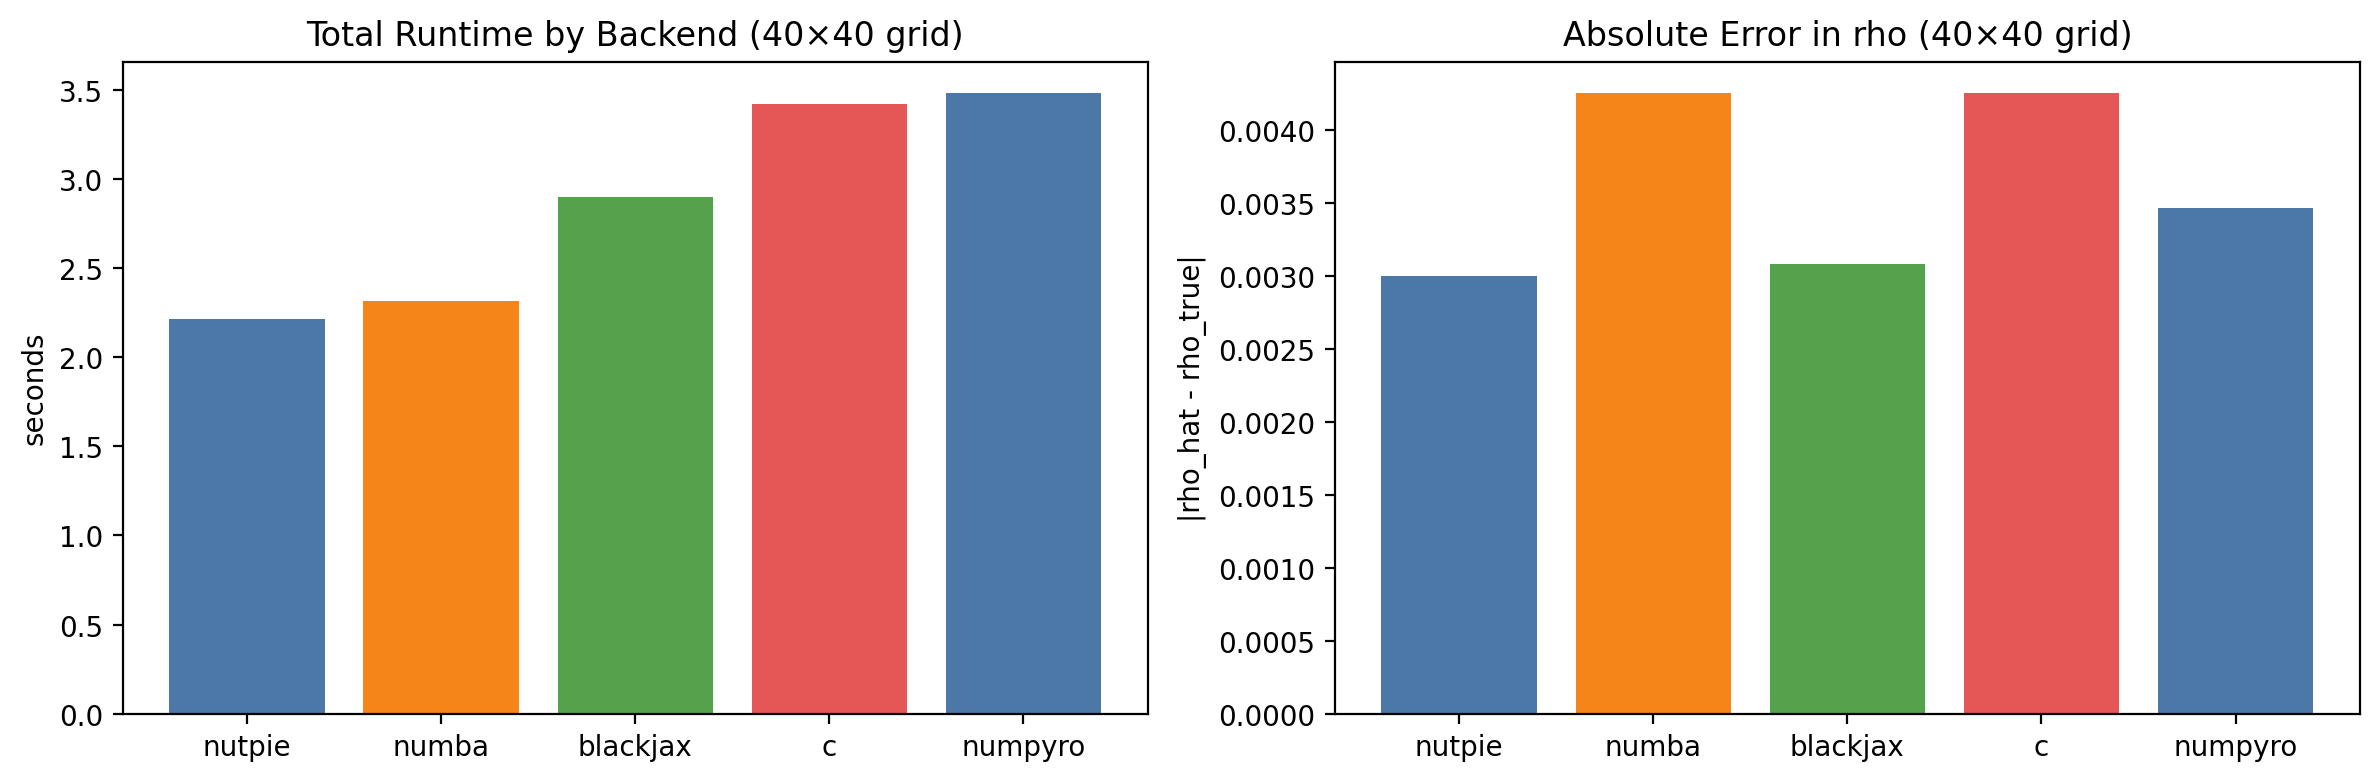

In [9]:
ok_full = results_full[results_full["total_time_s"].notna()].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not ok_full.empty:
    axes[0].bar(
        ok_full["backend"],
        ok_full["total_time_s"],
        color=["#4c78a8", "#f58518", "#54a24b", "#e45756"][: len(ok_full)],
    )
    axes[0].set_title("Total Runtime by Backend (40×40 grid)")
    axes[0].set_ylabel("seconds")

    axes[1].bar(
        ok_full["backend"],
        ok_full["rho_abs_error"],
        color=["#4c78a8", "#f58518", "#54a24b", "#e45756"][: len(ok_full)],
    )
    axes[1].set_title("Absolute Error in rho (40×40 grid)")
    axes[1].set_ylabel("|rho_hat - rho_true|")
else:
    axes[0].text(0.5, 0.5, "No successful backend runs", ha="center", va="center")
    axes[1].text(0.5, 0.5, "No successful backend runs", ha="center", va="center")
    axes[0].set_axis_off()
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## Reading The Results

Interpret the tables and plots with two constraints in mind:

- these settings are still benchmark-sized, even on the larger 40×40 grid